In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [39]:
df = pd.read_excel(r"/content/cgpaPRED.xls")

In [40]:
df.head()

,SEM 1,SEM 2,SEM 3,SEM 4,SEM 5
0,6.60,7.60,6.90,7.22,7.08
1,7.77,7.22,7.00,7.90,7.47
2,6.90,6.00,7.12,7.54,6.89
3,5.50,6.60,6.70,6.50,6.33
4,7.20,6.00,7.21,7.70,7.03


In [41]:
df.columns

Index(['SEM 1', 'SEM 2', 'SEM 3', 'SEM 4', 'SEM 5'], dtype='object')

In [42]:
df.isnull().sum()

,0
SEM 1,0
SEM 2,0
SEM 3,0
SEM 4,0
SEM 5,0


In [43]:
for i in df.columns:
  print(df[i].dtype)

float64
float64
float64
float64
float64


In [44]:
x = df.drop('SEM 5',axis = 1)

In [45]:
y = df['SEM 5']

In [46]:
'''for i in df.columns:
  print(df[i].unique())'''

'for i in df.columns:\n  print(df[i].unique())'

In [47]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 13)

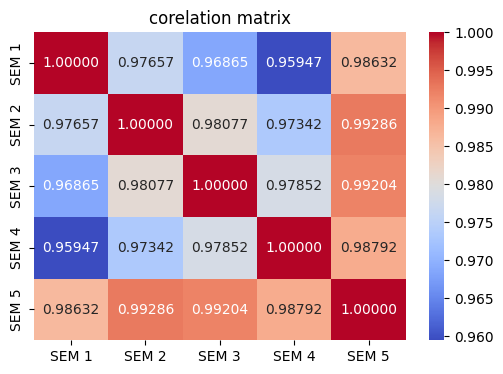

In [48]:
corr_matrix = df.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.5f')
plt.title('corelation matrix')
plt.show()

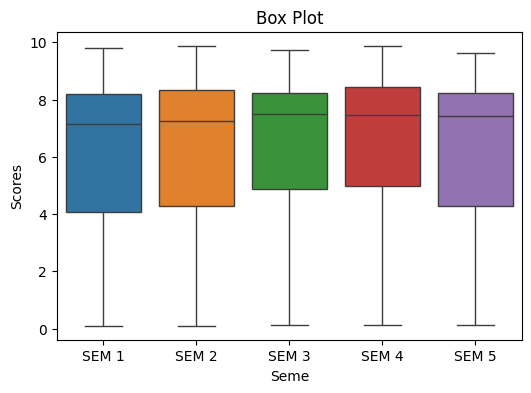

In [49]:

plt.figure(figsize=(6,4))
sns.boxplot(data=df)
plt.title('Box Plot')
plt.xlabel('Seme')
plt.ylabel('Scores')
plt.show()

In [50]:
x_LR_train = x_train[['SEM 2']]
x_LR_test = x_test[['SEM 2']]

In [51]:
model = LinearRegression()

In [52]:
model.fit(x_LR_train,y_train)

LinearRegression()

In [53]:
y_pred_lr = model.predict(x_LR_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
print("Mean Squared Error:", mse_lr)
print("R-squared:", r2_lr)
print("Mean Absolute Error:", mae_lr)
print("Root Mean Squared Error:", rmse_lr)

Mean Squared Error: 0.11806884201827506
R-squared: 0.988509123109074
Mean Absolute Error: 0.25920490435500204
Root Mean Squared Error: 0.3436114695674099


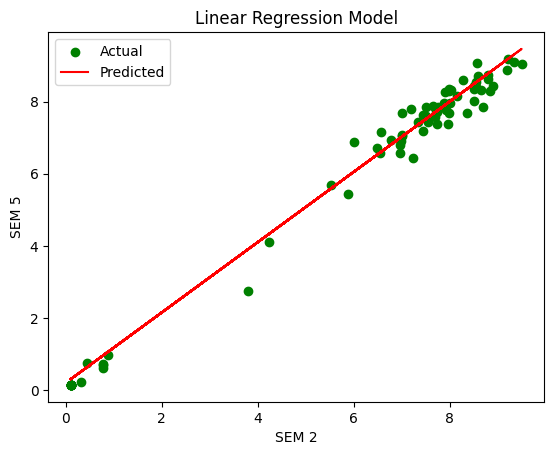

In [54]:
plt.scatter(x_LR_test, y_test, color='green', label='Actual')
plt.plot(x_LR_test, y_pred_lr, color='red', linewidth=1.5, label='Predicted')
plt.xlabel('SEM 2')
plt.ylabel('SEM 5')
plt.title('Linear Regression Model')
plt.legend()
plt.show()

In [55]:

model.fit(x_train,y_train)


LinearRegression()

In [56]:
model.predict(x_test)

array([8.72094571, 7.68433632, 0.72087315, 7.57380871, 9.18841572,
       0.9607648 , 7.90875762, 7.83853878, 5.44233638, 7.04905822,
       0.13855518, 7.78142716, 6.89095483, 7.85351756, 8.55854981,
       7.95627985, 6.92174043, 0.13855518, 8.42621769, 8.26097176,
       7.08392049, 6.58659059, 7.18667887, 0.69088046, 8.31643127,
       0.13855518, 0.13855518, 7.69889003, 6.94633441, 8.62105855,
       8.323364  , 0.13855518, 0.13855518, 2.75899962, 0.13855518,
       4.10496709, 9.09859104, 7.17348632, 9.04122609, 7.95866405,
       7.39422888, 7.79362366, 7.89098947, 7.68091479, 6.80665768,
       7.44150038, 8.45165388, 9.06568372, 8.87877182, 8.33835943,
       8.02407323, 0.75067708, 8.17367314, 7.44390087, 8.29134608,
       6.58934698, 6.45216294, 7.86203352, 0.13855518, 0.13855518,
       8.72603491, 7.61616512, 5.70194048, 0.60608754, 8.40616709,
       7.39153297, 7.71634934, 7.58631184, 0.13855518, 7.73880901,
       6.7216364 , 0.13855518, 8.29574946, 8.60340535, 8.34873

In [57]:

y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 7.035646043208423e-06
R-squared: 0.9999993152660672
Mean Absolute Error: 0.002307107788789961
Root Mean Squared Error: 0.0026524792257826306


In [58]:
simple_lr_metrics_data = {
    'Metric': ['MSE', 'R-squared', 'MAE', 'RMSE'],
    'Value': [mse_lr, r2_lr, mae_lr, rmse_lr]
}
simple_lr_metrics_df = pd.DataFrame(simple_lr_metrics_data)

/tmp/ipykernel_2528/812754459.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Value', data=simple_lr_metrics_df, palette='viridis')


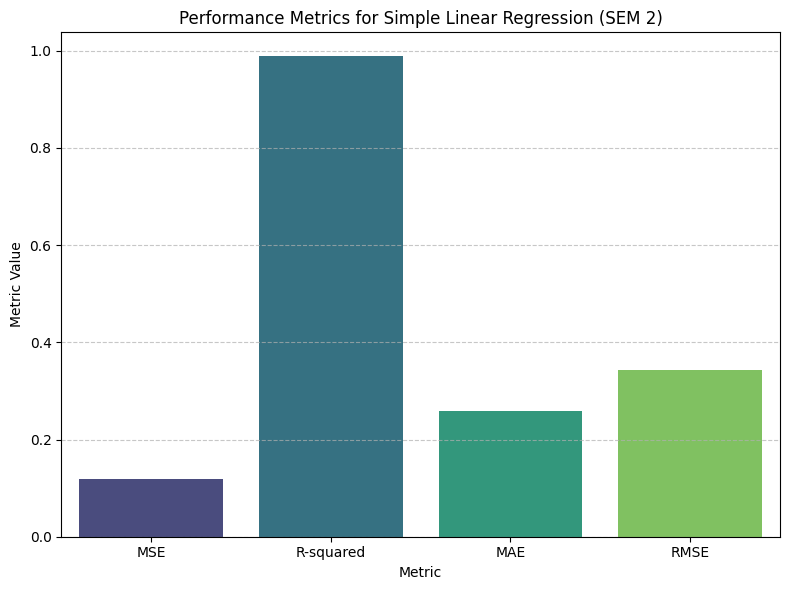

In [59]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Metric', y='Value', data=simple_lr_metrics_df, palette='viridis')
plt.title('Performance Metrics for Simple Linear Regression (SEM 2)')
plt.ylabel('Metric Value')
plt.xlabel('Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

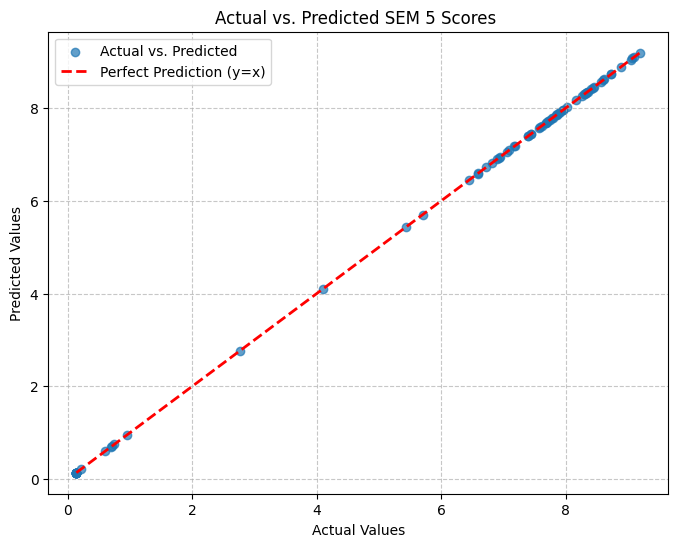

In [ ]:
'''plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, label='Actual vs. Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction (y=x)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted SEM 5 Scores ')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()'''